# Score Correlation Across 3 Seeds

This notebook measures how stable difficulty scores are across seeds.

## Input
- Three paths to score-result JSON files (typically `score_results.json`)

## Output
- Pairwise Pearson and Spearman correlations
- Correlation heatmaps
- Per-image score stability statistics (std across seeds)
- Most unstable images

In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt


def rankdata(arr: np.ndarray) -> np.ndarray:
    order = np.argsort(arr)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(len(arr), dtype=float)
    vals, inv, counts = np.unique(arr, return_inverse=True, return_counts=True)
    for i, c in enumerate(counts):
        if c > 1:
            idx = np.where(inv == i)[0]
            ranks[idx] = ranks[idx].mean()
    return ranks + 1.0


def safe_pearson(x: np.ndarray, y: np.ndarray) -> float:
    if len(x) < 2:
        return float("nan")
    if np.allclose(x, x[0]) or np.allclose(y, y[0]):
        return float("nan")
    return float(np.corrcoef(x, y)[0, 1])


def safe_spearman(x: np.ndarray, y: np.ndarray) -> float:
    if len(x) < 2:
        return float("nan")
    rx = rankdata(x)
    ry = rankdata(y)
    return safe_pearson(rx, ry)


def load_score_map(score_path: str | Path) -> dict[str, float]:
    p = Path(score_path)
    if not p.exists():
        raise FileNotFoundError(f"Score file not found: {p}")

    with open(p, "r", encoding="utf-8") as f:
        data = json.load(f)

    image_difficulties = data.get("image_difficulties", [])
    if not isinstance(image_difficulties, list) or len(image_difficulties) == 0:
        raise ValueError(f"No valid image_difficulties in: {p}")

    score_map: dict[str, float] = {}
    for item in image_difficulties:
        raw_path = item.get("image_path", "")
        score = item.get("difficulty_score", None)
        if not raw_path or score is None:
            continue
        key = Path(raw_path).name
        score_map[key] = float(score)

    if len(score_map) == 0:
        raise ValueError(f"No usable image scores in: {p}")

    return score_map

In [ ]:
# Set exactly 3 score-result file paths here
# SCORE_PATHS = [
#     "/home/khanh/Projects/DifficultyAgri/.cache_result/no_trad_aug/minneapple/scoring/seed_123/score_results.json",
#     "/home/khanh/Projects/DifficultyAgri/.cache_result/no_trad_aug/minneapple/scoring/seed_456/score_results.json",
#     "/home/khanh/Projects/DifficultyAgri/.cache_result/no_trad_aug/minneapple/scoring/seed_789/score_results.json"
# ]

# SCORE_PATHS = [
#     "/home/khanh/Projects/DifficultyAgri/results/04_train_and_scoring_mulseed/seed_123/Step_3_Scoring_Dataset/score_results.json",
#     "/home/khanh/Projects/DifficultyAgri/results/04_train_and_scoring_mulseed/seed_456/Step_3_Scoring_Dataset/score_results.json",
#     "/home/khanh/Projects/DifficultyAgri/results/04_train_and_scoring_mulseed/seed_789/Step_3_Scoring_Dataset/score_results.json"
# ]

SCORE_PATHS = [
    "/home/khanh/Projects/DifficultyAgri/.cache_result/no_trad_aug/gwhd/scoring/seed_123/score_results.json",
    "/home/khanh/Projects/DifficultyAgri/.cache_result/no_trad_aug/gwhd/scoring/seed_456/score_results.json",
    "/home/khanh/Projects/DifficultyAgri/.cache_result/no_trad_aug/gwhd/scoring/seed_789/score_results.json"
]

# SCORE_PATHS = [
#     "/home/khanh/Projects/DifficultyAgri/.cache_result/no_trad_aug/minneapple/scoring/seed_123/score_results.json",
#     "/home/khanh/Projects/DifficultyAgri/.cache_result/no_trad_aug/minneapple/scoring/seed_456/score_results.json",
#     "/home/khanh/Projects/DifficultyAgri/.cache_result/no_trad_aug/minneapple/scoring/seed_789/score_results.json"
# ]

# SCORE_PATHS = [
#     "/home/khanh/Projects/DifficultyAgri/.cache_result/no_trad_aug/minneapple/scoring/seed_123/score_results.json",
#     "/home/khanh/Projects/DifficultyAgri/.cache_result/no_trad_aug/minneapple/scoring/seed_456/score_results.json",
#     "/home/khanh/Projects/DifficultyAgri/.cache_result/no_trad_aug/minneapple/scoring/seed_789/score_results.json"
# ]

# SCORE_PATHS = [
#     "/home/khanh/Projects/DifficultyAgri/.cache_result/no_trad_aug/minneapple/scoring/seed_123/score_results.json",
#     "/home/khanh/Projects/DifficultyAgri/.cache_result/no_trad_aug/minneapple/scoring/seed_456/score_results.json",
#     "/home/khanh/Projects/DifficultyAgri/.cache_result/no_trad_aug/minneapple/scoring/seed_789/score_results.json"
# ]


# Extract seed labels from paths (e.g., "seed_123", "seed_456", "seed_789")
SEED_LABELS = [Path(p).parent.name for p in SCORE_PATHS]

if len(SCORE_PATHS) != 3:
    raise ValueError("Please provide exactly 3 score file paths in SCORE_PATHS.")
if len(SEED_LABELS) != 3:
    raise ValueError("Please provide exactly 3 labels in SEED_LABELS.")

score_maps = [load_score_map(p) for p in SCORE_PATHS]
for lbl, m in zip(SEED_LABELS, score_maps):
    print(f"Loaded {lbl}: {len(m)} images with scores")

common_images = set(score_maps[0].keys())
for m in score_maps[1:]:
    common_images &= set(m.keys())

common_images = sorted(common_images)
if len(common_images) < 2:
    raise ValueError("Too few overlapping images across the 3 files.")

# Matrix shape: [num_images, 3]
score_matrix = np.array([[m[k] for m in score_maps] for k in common_images], dtype=float)
print(f"\nCommon images used for correlation: {len(common_images)}")
print(f"Score matrix shape: {score_matrix.shape}")

Loaded seed_123: 2700 images with scores
Loaded seed_456: 2700 images with scores
Loaded seed_789: 2700 images with scores

Common images used for correlation: 2700
Score matrix shape: (2700, 3)


In [3]:
# Pairwise correlations across the 3 seeds
pearson_mat = np.eye(3, dtype=float)
spearman_mat = np.eye(3, dtype=float)

for i in range(3):
    for j in range(i + 1, 3):
        x = score_matrix[:, i]
        y = score_matrix[:, j]
        pearson_ij = safe_pearson(x, y)
        spearman_ij = safe_spearman(x, y)
        pearson_mat[i, j] = pearson_mat[j, i] = pearson_ij
        spearman_mat[i, j] = spearman_mat[j, i] = spearman_ij

print("Pairwise Pearson correlations:")
for i in range(3):
    for j in range(i + 1, 3):
        print(f"  {SEED_LABELS[i]} vs {SEED_LABELS[j]}: {pearson_mat[i, j]:.6f}")

print("\nPairwise Spearman correlations:")
for i in range(3):
    for j in range(i + 1, 3):
        print(f"  {SEED_LABELS[i]} vs {SEED_LABELS[j]}: {spearman_mat[i, j]:.6f}")

upper_idx = np.triu_indices(3, k=1)
print("\nMean pairwise Pearson:", float(np.nanmean(pearson_mat[upper_idx])))
print("Mean pairwise Spearman:", float(np.nanmean(spearman_mat[upper_idx])))

Pairwise Pearson correlations:
  seed_123 vs seed_456: 0.864831
  seed_123 vs seed_789: 0.855575
  seed_456 vs seed_789: 0.869653

Pairwise Spearman correlations:
  seed_123 vs seed_456: 0.888809
  seed_123 vs seed_789: 0.901280
  seed_456 vs seed_789: 0.883342

Mean pairwise Pearson: 0.863353196939924
Mean pairwise Spearman: 0.8911437446572225


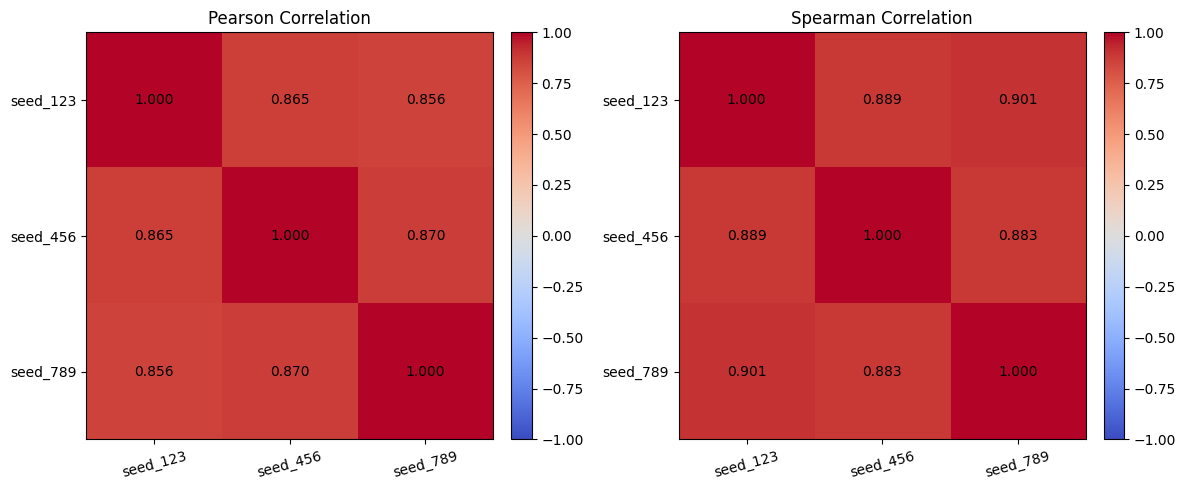

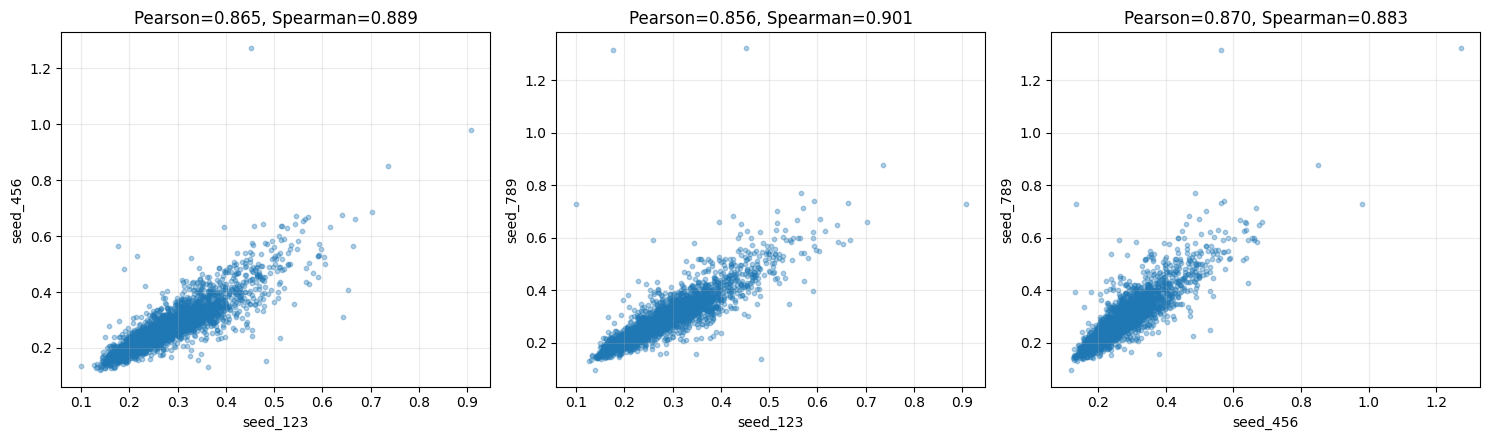

In [4]:
# Correlation heatmaps
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(pearson_mat, vmin=-1, vmax=1, cmap="coolwarm")
axes[0].set_title("Pearson Correlation")
axes[0].set_xticks(range(3), SEED_LABELS, rotation=15)
axes[0].set_yticks(range(3), SEED_LABELS)
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, f"{pearson_mat[i, j]:.3f}", ha="center", va="center")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(spearman_mat, vmin=-1, vmax=1, cmap="coolwarm")
axes[1].set_title("Spearman Correlation")
axes[1].set_xticks(range(3), SEED_LABELS, rotation=15)
axes[1].set_yticks(range(3), SEED_LABELS)
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, f"{spearman_mat[i, j]:.3f}", ha="center", va="center")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Pairwise scatter plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
pairs = [(0, 1), (0, 2), (1, 2)]
for ax, (i, j) in zip(axes, pairs):
    ax.scatter(score_matrix[:, i], score_matrix[:, j], s=10, alpha=0.35)
    ax.set_xlabel(SEED_LABELS[i])
    ax.set_ylabel(SEED_LABELS[j])
    ax.set_title(
        f"Pearson={pearson_mat[i, j]:.3f}, Spearman={spearman_mat[i, j]:.3f}"
    )
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

Mean std across images: 0.020038
Median std across images: 0.015382
P90 std across images: 0.038703
P95 std across images: 0.050586

Top 20 most unstable images (by std across seeds):
 1. 20ac5e00-39a1-46a9-8193-1d6ee22a1178.png | mean=0.685314 | std=0.472073 | cv=0.688843
 2. ee9835e9-a110-4619-939c-459f70225356.png | mean=1.015196 | std=0.398337 | cv=0.392374
 3. ba979230-4132-416d-9240-bc445bc1fe9e.png | mean=0.320418 | std=0.287841 | cv=0.898331
 4. 0a82cf5a-83df-453e-bc85-2852cce9ddc2.png | mean=0.258312 | std=0.159330 | cv=0.616813
 5. 7b573dd6-f0b4-4c22-a31e-dd52ba2dc467.png | mean=0.371411 | std=0.155333 | cv=0.418223
 6. 1b05469e-768e-4b1d-97d3-8e3937d4f57e.png | mean=0.512391 | std=0.144054 | cv=0.281140
 7. f3449389-a9f1-479e-ba85-18cbc6f63e8f.png | mean=0.332086 | std=0.140500 | cv=0.423083
 8. 3464f966-e8dc-4f20-9522-1d64c8a32aac.png | mean=0.429128 | std=0.136040 | cv=0.317014
 9. 5fcc8fcf-1362-400e-8bd7-9885809db228.png | mean=0.297953 | std=0.130086 | cv=0.436597
10. 69

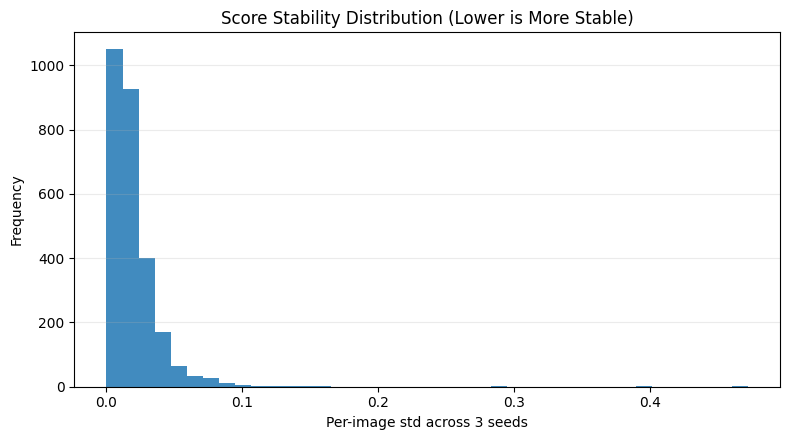

In [5]:
# Per-image stability across seeds
per_image_mean = np.mean(score_matrix, axis=1)
per_image_std = np.std(score_matrix, axis=1)
per_image_cv = per_image_std / np.clip(np.abs(per_image_mean), 1e-8, None)

print(f"Mean std across images: {float(np.mean(per_image_std)):.6f}")
print(f"Median std across images: {float(np.median(per_image_std)):.6f}")
print(f"P90 std across images: {float(np.quantile(per_image_std, 0.90)):.6f}")
print(f"P95 std across images: {float(np.quantile(per_image_std, 0.95)):.6f}")

# Show top unstable images
top_k = 20
top_idx = np.argsort(per_image_std)[-top_k:][::-1]
print(f"\nTop {top_k} most unstable images (by std across seeds):")
for rank, idx in enumerate(top_idx, start=1):
    print(
        f"{rank:2d}. {common_images[idx]} | mean={per_image_mean[idx]:.6f} | "
        f"std={per_image_std[idx]:.6f} | cv={per_image_cv[idx]:.6f}"
    )

plt.figure(figsize=(8, 4.5))
plt.hist(per_image_std, bins=40, alpha=0.85)
plt.xlabel("Per-image std across 3 seeds")
plt.ylabel("Frequency")
plt.title("Score Stability Distribution (Lower is More Stable)")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## How to interpret results

- High stability: pairwise correlations close to 1.0 and low per-image std.
- Lower stability: weaker correlations and a long right-tail in per-image std histogram.
- Start by checking mean pairwise Spearman for rank consistency, then inspect top unstable images.